<a href="https://colab.research.google.com/github/onlyforstudy7770-cpu/DeepFake-voice-detection-project/blob/main/Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv ("500hits.csv" , encoding = 'latin-1')
df.head()

In [ ]:
!unzip -q "/content/drive/MyDrive/ASVsfoop_data/AA_lol.zip" -d "/content/my_dataset"

In [ ]:
!unzip -q "/content/drive/MyDrive/ASVsfoop_data/eval_mfcc.zip" -d "/content/my_eval"


In [ ]:
import numpy as np
import pandas as pd
import os
import glob
from tqdm import tqdm

# 1. Setup Paths
mfcc_folder_path = "/content/my_dataset"
csv_file_path = "/content/drive/MyDrive/ASVsfoop_data/train.csv"

# 2. Load the CSV and create a mapping dictionary
# This creates a fast lookup: { 'filename': target_value }
print("Loading CSV...")
df = pd.read_csv(csv_file_path)

# Ensure the 'filename' column is a string to avoid matching errors
df['filename'] = df['filename'].astype(str)
target_map = dict(zip(df["filename"], df["target"]))

# 3. Get list of .npy files
file_paths = glob.glob(os.path.join(mfcc_folder_path, "*.npy"))
file_paths.sort()  # Sorting ensures deterministic order

X_train_list = []
y_train_list = []

print(f"Found {len(file_paths)} files. Starting data loading...")

# 4. Loop through files with a progress bar
for file_path in tqdm(file_paths):
    # Extract filename from path (e.g., "/content/.../LA_T_123.flac.npy" -> "LA_T_123.flac.npy")
    full_filename = os.path.basename(file_path)

    # Clean the filename to match CSV keys
    # Removing ".flac.npy" to get just the ID (e.g., "LA_T_123")
    # Adjust this replace logic if your CSV has ".flac" in the names
    csv_key = full_filename.replace(".flac.npy", "").replace(".npy", "")

    # Only load if the file exists in our CSV map
    if csv_key in target_map:
        # Load the MFCC data
        data = np.load(file_path)

        # Optional: Flatten the data if you are using SVM/Logistic Regression
        # data = data.ravel()

        X_train_list.append(data)
        y_train_list.append(int(target_map[csv_key]))
    else:
        # Optional: Print if a file is not found in CSV
        pass

# 5. Convert lists to numpy arrays
X_train = np.array(X_train_list)
y_train = np.array(y_train_list)

print("\nLoading Complete.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Loading CSV...
Found 25380 files. Starting data loading...


100%|██████████| 25380/25380 [00:06<00:00, 3931.95it/s]



Loading Complete.
X_train shape: (25380, 40, 126)
y_train shape: (25380,)


In [ ]:
import numpy as np
import pandas as pd
import os
import glob
from tqdm import tqdm

# 1. Setup Paths
mfcc_folder_path = "/content/my_eval/eval_mfcc"
csv_file_path = "/content/drive/MyDrive/ASVsfoop_data/eval.csv"

# 2. Load the CSV and create a mapping dictionary
# This creates a fast lookup: { 'filename': target_value }
print("Loading CSV...")
df = pd.read_csv(csv_file_path)

# Ensure the 'filename' column is a string to avoid matching errors
df['filename'] = df['filename'].astype(str)
target_map = dict(zip(df["filename"], df["target"]))

# 3. Get list of .npy files
file_paths = glob.glob(os.path.join(mfcc_folder_path, "*.npy"))
file_paths.sort()  # Sorting ensures deterministic order

X_train_list = []
y_train_list = []

print(f"Found {len(file_paths)} files. Starting data loading...")

# 4. Loop through files with a progress bar
for file_path in tqdm(file_paths):
    # Extract filename from path (e.g., "/content/.../LA_T_123.flac.npy" -> "LA_T_123.flac.npy")
    full_filename = os.path.basename(file_path)

    # Clean the filename to match CSV keys
    # Removing ".flac.npy" to get just the ID (e.g., "LA_T_123")
    # Adjust this replace logic if your CSV has ".flac" in the names
    csv_key = full_filename.replace(".flac.npy", "").replace(".npy", "")

    # Only load if the file exists in our CSV map
    if csv_key in target_map:
        # Load the MFCC data
        data = np.load(file_path)

        # Optional: Flatten the data if you are using SVM/Logistic Regression
        # data = data.ravel()

        X_train_list.append(data)
        y_train_list.append(int(target_map[csv_key]))
    else:
        # Optional: Print if a file is not found in CSV
        pass

# 5. Convert lists to numpy arrays
X_test = np.array(X_train_list)
y_test = np.array(y_train_list)

print("\nLoading Complete.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Loading CSV...
Found 71237 files. Starting data loading...


100%|██████████| 71237/71237 [00:41<00:00, 1729.15it/s]



Loading Complete.
X_train shape: (16243, 5040)
y_train shape: (16243,)


In [ ]:
X_train_2d = X_train.reshape(X_train.shape[0], -1)

In [ ]:
X_test_2d = X_test.reshape(X_test.shape[0], -1)


In [ ]:
print(f"Original shape: {X_train.shape}")
print(f"New shape:      {X_train_2d.shape}")

Original shape: (20304, 40, 126)
New shape:      (20304, 5040)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_train_2d, y_train, test_size=0 , random_state = 11)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

In [ ]:
rf.fit(X_train_2d, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
y_pred = rf.predict(X_test_2d)

In [ ]:
rf.score(X_test_2d , y_test)

0.9000379016522313

In [ ]:
from sklearn.metrics import classification_report , confusion_matrix

In [ ]:
print (classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.51      0.55      0.53      7355
           1       0.95      0.94      0.94     63882

    accuracy                           0.90     71237
   macro avg       0.73      0.75      0.74     71237
weighted avg       0.90      0.90      0.90     71237



In [ ]:
# Assuming X_train is shape (25000, Time_Steps, 13)

# 1. Calculate Mean across time (axis=1)
mean_features = np.mean(X_train, axis=1)

# 2. Calculate Std Deviation across time (axis=1)
std_features = np.std(X_train, axis=1)

# 3. Combine them side-by-side
# New shape will be (25000, 26)
X_train_agg = np.concatenate([mean_features, std_features], axis=1)

print(f"New feature shape: {X_train_agg.shape}")

AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
import numpy as np
import pandas as pd
import os
import glob
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.under_sampling import RandomUnderSampler

# --- 1. SETUP PATHS ---
dataset_path = "/content/my_dataset"
csv_path = "/content/drive/MyDrive/ASVsfoop_data/train.csv"

# --- 2. LOAD MAP ---
df = pd.read_csv(csv_path)
df['filename'] = df['filename'].astype(str)
target_map = dict(zip(df["filename"], df["target"]))

# --- 3. LOAD DATA (Keep it 3D temporarily) ---
file_paths = glob.glob(os.path.join(dataset_path, "*.npy"))
file_paths.sort()

X_list = []
y_list = []

print("Loading data...")
for file_path in tqdm(file_paths):
    filename = os.path.basename(file_path)
    key = filename.replace(".flac.npy", "").replace(".npy", "")

    if key in target_map:
        # Load raw 2D matrix (Time x Features)
        data = np.load(file_path)

        # --- CRITICAL STEP: FEATURE ENGINEERING ---
        # Instead of saving the huge matrix, we calculate Mean & Std immediately.
        # This saves RAM and solves the "Time Misalignment" problem.

        # Calculate Mean across Time (axis 0 for a single file)
        mean_feat = np.mean(data, axis=0)

        # Calculate Std across Time (axis 0 for a single file)
        std_feat = np.std(data, axis=0)

        # Combine them: [Mean_1, Mean_2... Std_1, Std_2...]
        combined_feat = np.concatenate([mean_feat, std_feat])

        X_list.append(combined_feat)
        y_list.append(target_map[key])

X = np.array(X_list)
y = np.array(y_list)

print(f"\nFinal Feature Shape: {X.shape}") # Should be (N, 26) or (N, 40) depending on MFCC count

# --- 4. BALANCE DATA (Undersampling) ---
print("Balancing classes...")
rus = RandomUnderSampler(random_state=42)
X_balanced, y_balanced = rus.fit_resample(X, y)

print(f"Training with {len(y_balanced)} samples.")

# --- 5. TRAIN MODEL ---
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_balanced, y_balanced)

# --- 6. TEST ---
# Testing on the full (imbalanced) set to see real performance
y_pred = rf.predict(X)
print("\nClassification Report:")
print(classification_report(y, y_pred))

Loading data...


100%|██████████| 25380/25380 [00:17<00:00, 1459.31it/s]



Final Feature Shape: (25380, 252)
Balancing classes...
Training with 5160 samples.
Training Random Forest...

Classification Report:
              precision    recall  f1-score   support

           0       0.41      1.00      0.58      2580
           1       1.00      0.83      0.91     22800

    accuracy                           0.85     25380
   macro avg       0.70      0.92      0.74     25380
weighted avg       0.94      0.85      0.88     25380



In [ ]:
# 1. Get the probability scores instead of just 0/1
# This returns a list like: [Prob_Class_0, Prob_Class_1]
probs = rf.predict_proba(X)

# 2. We are interested in the probability of being Class 1 (Spoof)
probs_spoof = probs[:, 1]

# 3. Custom Threshold: Only call it "Spoof" (1) if model is very sure (> 20%)
# Lowering this threshold makes the model MORE aggressive at catching Spoofs,
# which reduces the False "Real" predictions.
threshold = 0.2
y_pred_new = (probs_spoof > threshold).astype(int)

print(classification_report(y, y_pred_new))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93      2580
           1       1.00      0.99      0.99     22800

    accuracy                           0.99     25380
   macro avg       0.95      0.97      0.96     25380
weighted avg       0.99      0.99      0.99     25380



IndexError: list index out of range

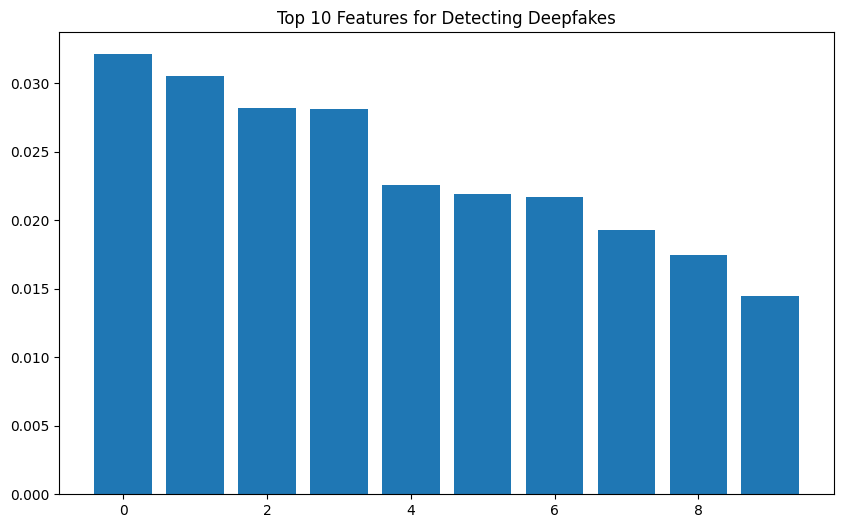

In [64]:
import matplotlib.pyplot as plt

# Get feature importances
importances = rf.feature_importances_

# Create a list of feature names (0-12 are Means, 13-25 are Stds)
feature_names = [f"Mean_MFCC_{i}" for i in range(13)] + [f"Std_MFCC_{i}" for i in range(13)]

# Sort them
indices = np.argsort(importances)[::-1]

# Plot top 10 features
plt.figure(figsize=(10, 6))
plt.title("Top 10 Features for Detecting Deepfakes")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), [feature_names[i] for i in indices[:10]], rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import joblib

# Save the model to your Drive
model_filename = "/content/drive/MyDrive/ASVsfoop_data/rf_model_99acc.pkl"
joblib.dump(rf, model_filename)

print(f"Model saved to {model_filename}")

Model saved to /content/drive/MyDrive/ASVsfoop_data/rf_model_99acc.pkl


In [ ]:
features = pd.DataFrame(rf.feature_importances_ , index = y_train)

ValueError: Shape of passed values is (5040, 1), indices imply (16243, 1)